In [1]:
#load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('US_Accidents_March23.csv', nrows=100000)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()
print("\nData types:")
print(df.dtypes.value_counts())
print("\nMissing values in key columns:")
key_cols = ['Severity', 'Start_Time', 'Weather_Condition', 'State', 'City', 'Sunrise_Sunset']
print(df[key_cols].isnull().sum())

Shape: (100000, 46)

Columns: ['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']

First 5 rows:

Data types:
object     20
bool       13
float64    12
int64       1
dtype: int64

Missing values in key columns:
Severity                0
Start_Time              0
Weather_Condition    1604
State                   0
City                    1
Sunrise_Sunset          1
dtype: int64


In [2]:
#data cleaning# Convert Start_Time to datetime
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.day_name()
df['Month'] = df['Start_Time'].dt.month_name()
df['Year'] = df['Start_Time'].dt.year
df = df.dropna(subset=['Start_Time', 'Severity', 'Weather_Condition'])
print("Shape after cleaning:", df.shape)
print("\nSeverity distribution:")
print(df['Severity'].value_counts().sort_index())


Shape after cleaning: (98396, 50)

Severity distribution:
1       95
2    54133
3    44135
4       33
Name: Severity, dtype: int64


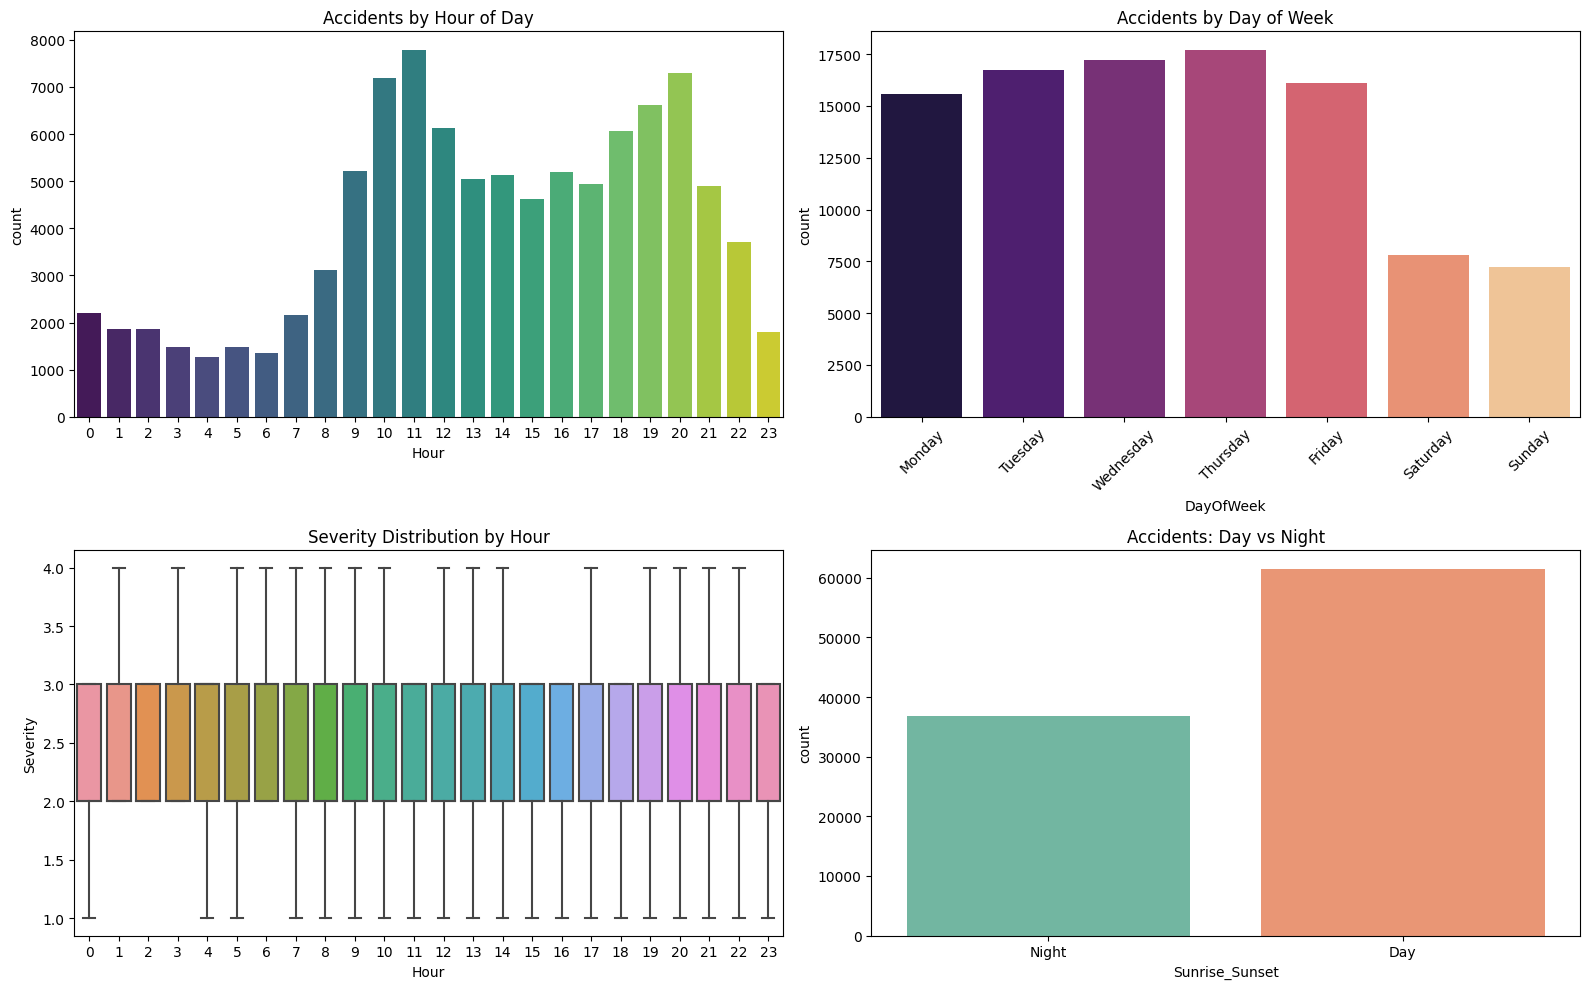

In [3]:
#eda
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.countplot(data=df, x='Hour', palette='viridis', ax=axes[0,0])
axes[0,0].set_title('Accidents by Hour of Day')
axes[0,0].set_xlabel('Hour')
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.countplot(data=df, x='DayOfWeek', order=day_order, palette='magma', ax=axes[0,1])
axes[0,1].set_title('Accidents by Day of Week')
axes[0,1].tick_params(axis='x', rotation=45)
sns.boxplot(data=df, x='Hour', y='Severity', ax=axes[1,0])
axes[1,0].set_title('Severity Distribution by Hour')
sns.countplot(data=df, x='Sunrise_Sunset', palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Accidents: Day vs Night')
plt.tight_layout()
plt.show()

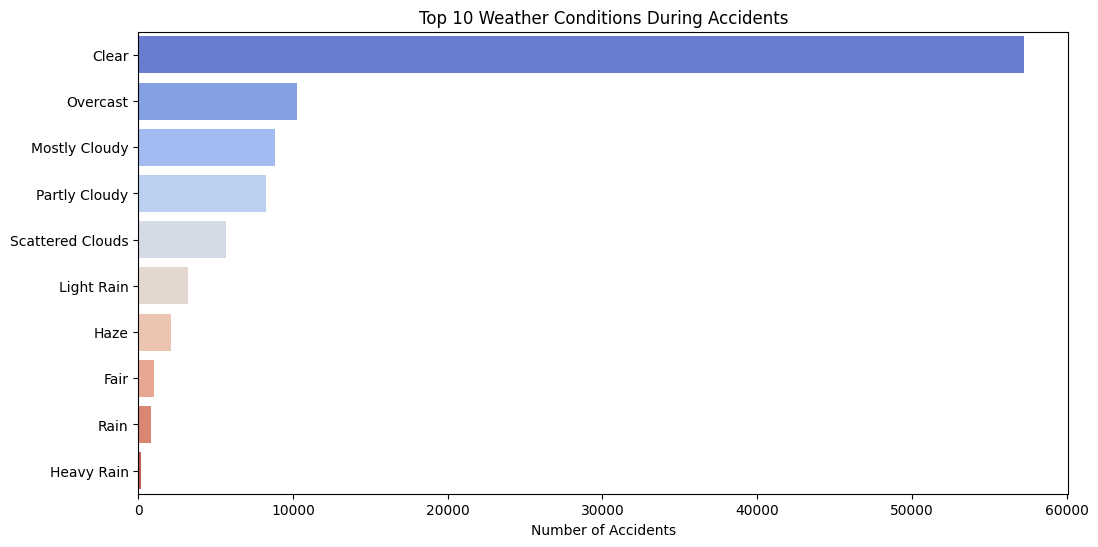

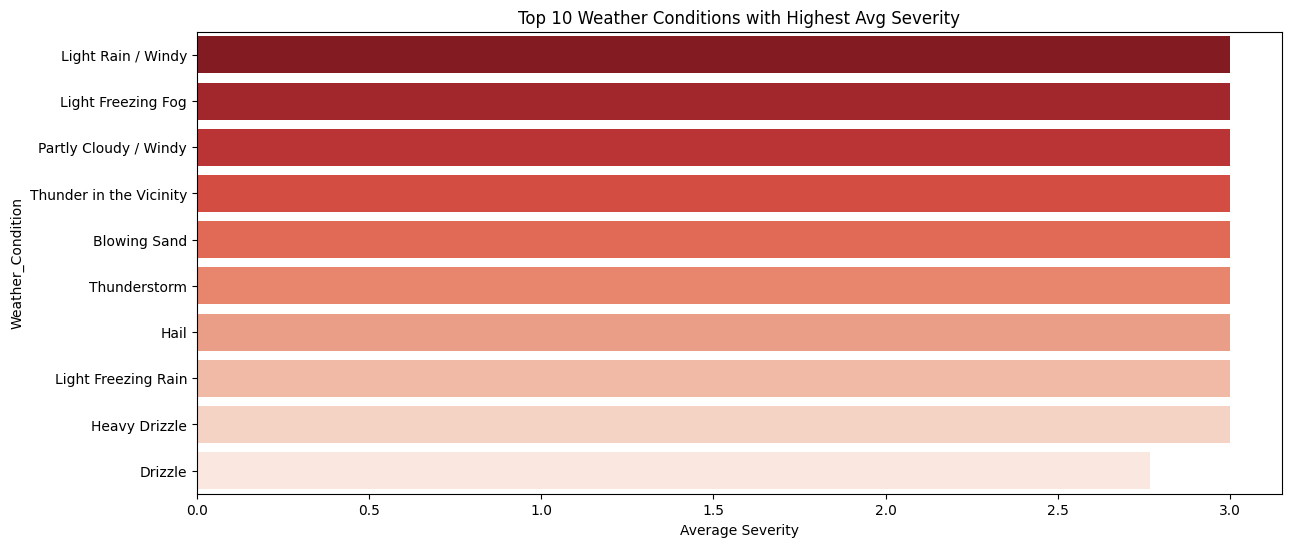

In [5]:
#weathre and road condition
plt.figure(figsize=(12,6))
top_weather = df['Weather_Condition'].value_counts().head(10)
sns.barplot(x=top_weather.values, y=top_weather.index, palette='coolwarm')
plt.title('Top 10 Weather Conditions During Accidents')
plt.xlabel('Number of Accidents')
plt.show()
plt.figure(figsize=(14,6))
weather_sev = df.groupby('Weather_Condition')['Severity'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=weather_sev.values, y=weather_sev.index, palette='Reds_r')
plt.title('Top 10 Weather Conditions with Highest Avg Severity')
plt.xlabel('Average Severity')
plt.show()

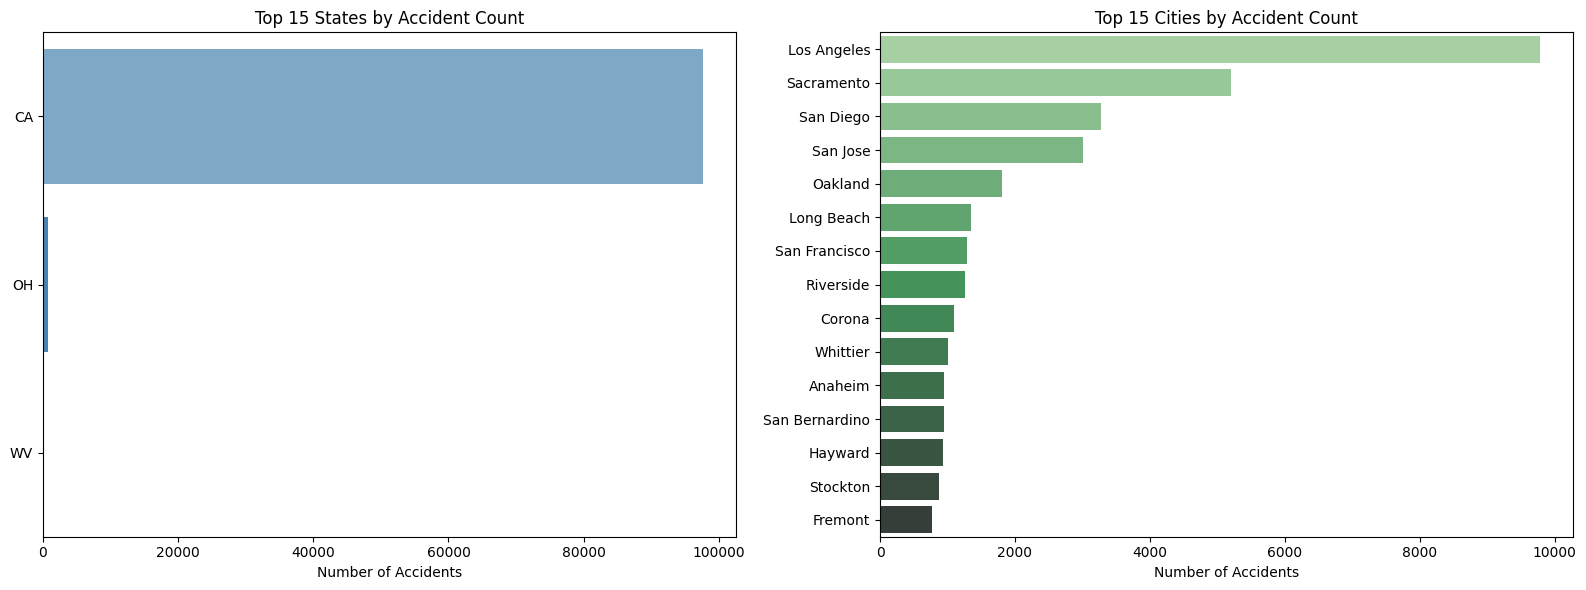

In [6]:
#accident hotspots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_states = df['State'].value_counts().head(15)
sns.barplot(x=top_states.values, y=top_states.index, palette='Blues_d', ax=axes[0])
axes[0].set_title('Top 15 States by Accident Count')
axes[0].set_xlabel('Number of Accidents')
top_cities = df['City'].value_counts().head(15)
sns.barplot(x=top_cities.values, y=top_cities.index, palette='Greens_d', ax=axes[1])
axes[1].set_title('Top 15 Cities by Accident Count')
axes[1].set_xlabel('Number of Accidents')
plt.tight_layout()
plt.show()

            Feature  Avg_Sev_With  Avg_Sev_Without  Difference
4          Junction      2.586014         2.432050    0.153963
6           Railway      2.510101         2.447494    0.062607
5           No_Exit      2.481481         2.448232    0.033250
1              Bump      2.416667         2.448265   -0.031599
8           Station      2.291775         2.453320   -0.161545
10  Traffic_Calming      2.269231         2.448392   -0.179161
2          Crossing      2.151802         2.468997   -0.317195
11   Traffic_Signal      2.164097         2.482216   -0.318120
9              Stop      2.114734         2.459646   -0.344912
0           Amenity      2.079576         2.451097   -0.371521
3          Give_Way      2.012821         2.448941   -0.436121
7        Roundabout      2.000000         2.448273   -0.448273


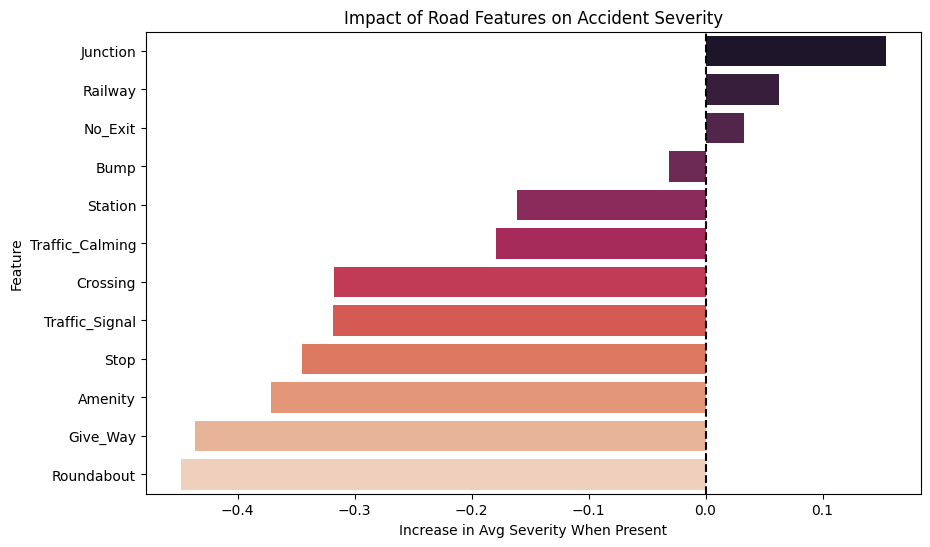

In [7]:
#factor analysis
road_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 
                 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 
                 'Traffic_Calming', 'Traffic_Signal']
feature_impact = []
for feature in road_features:
    if feature in df.columns:
        with_feature = df[df[feature] == True]['Severity'].mean()
        without_feature = df[df[feature] == False]['Severity'].mean()
        diff = with_feature - without_feature
        feature_impact.append({'Feature': feature, 'Avg_Sev_With': with_feature, 'Avg_Sev_Without': without_feature, 'Difference': diff})
impact_df = pd.DataFrame(feature_impact).sort_values('Difference', ascending=False)
print(impact_df)
plt.figure(figsize=(10,6))
sns.barplot(data=impact_df, x='Difference', y='Feature', palette='rocket')
plt.title('Impact of Road Features on Accident Severity')
plt.xlabel('Increase in Avg Severity When Present')
plt.axvline(0, color='black', linestyle='--')
plt.show()